[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Columns: Index(['section', 'name'], dtype='str')
  section                                               name
0       I                      live animals; animal products
1      II                                 Vegetable products
2     III  Animal or vegetable fats and oils and their cl...
3      IV  Prepared foodstuffs; beverages, spirits and vi...
4       V                                   Mineral products


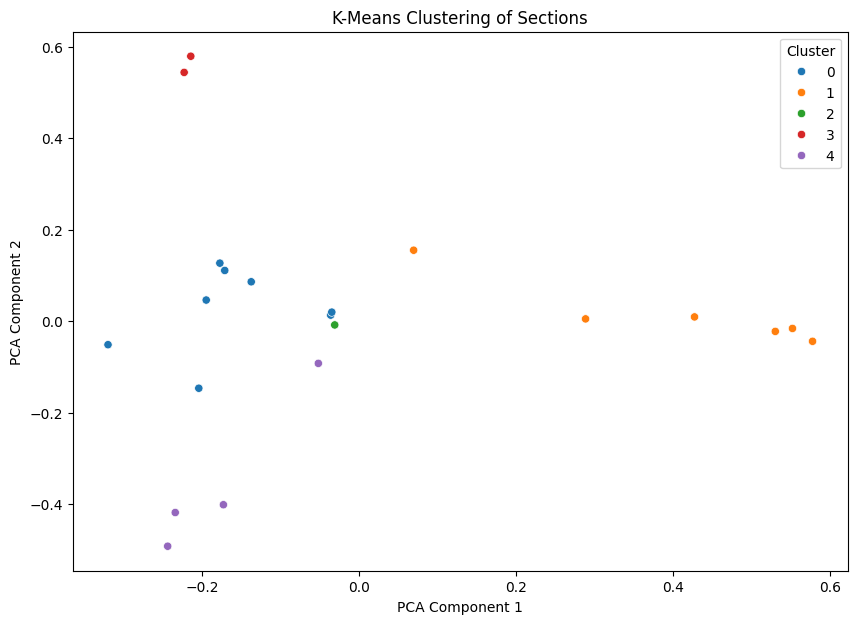


=== Cluster 0 ===
- IV Prepared foodstuffs; beverages, spirits and vinegar; tobacco and manufactured tobacco substitutes
- VII Plastics and articles thereof; rubber and articles thereof 
- VIII Raw hides and skins, leather, furskins and articles thereof; saddlery and harness; travel goods, handbags and similar containers; articles of animal gut (other than silk-worm gut)

=== Cluster 1 ===
- I live animals; animal products
- II Vegetable products
- III Animal or vegetable fats and oils and their cleavage products; prepared edible fats; animal or vegetable waxes

=== Cluster 2 ===
- XXI Works of art, collectors' pieces and antiques

=== Cluster 3 ===
- XIV Natural or cultured pearls, precious or semi-precious stones, precious metals, metals clad with precious metal and articles thereof; imitation jewellery; coin
- XV Base metals and articles of base metal

=== Cluster 4 ===
- XVI Machinery and mechanical appliances; electrical equipment; parts thereof; sound recorders and reproducers, 

In [2]:
# -------------------------------
# Import libraries
# -------------------------------
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# -------------------------------
# Download NLTK resources (only runs once)
# -------------------------------
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("sections.csv")

# Check columns
print("Columns:", df.columns)
print(df.head())

# -------------------------------
# NLP Preprocessing Setup
# -------------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [word for word in text.split() if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# -------------------------------
# Combine useful columns (FIXED)
# -------------------------------
df['combined_text'] = df['section'].astype(str) + " " + df['name'].astype(str)

# Apply preprocessing
df['clean_text'] = df['combined_text'].apply(preprocess_text)

# -------------------------------
# TF-IDF Vectorization
# -------------------------------
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])

# -------------------------------
# K-Means Clustering
# -------------------------------
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# -------------------------------
# PCA for Visualization
# -------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

# -------------------------------
# Plot Clusters
# -------------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(x='pca_x', y='pca_y', hue='cluster', data=df, palette='tab10')
plt.title("K-Means Clustering of Sections")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

# -------------------------------
# Review Cluster Samples
# -------------------------------
for i in range(num_clusters):
    print(f"\n=== Cluster {i} ===")
    samples = df[df['cluster'] == i]['combined_text'].head(3).values
    for s in samples:
        print("-", s)

# -------------------------------
# Top Terms per Cluster (VERY USEFUL)
# -------------------------------
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

print("\nTop terms per cluster:")
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")